# 01. EDA — ESS 배터리 수명 예측

**목적** : Batch 1·2·3 의 특성을 5개 질문으로 탐색하고, 그 결과를 근거로 모델 설계 전략을 수립한다.

| 구분 | 사용 데이터 |
|---|---|
| EDA | Batch 1 + Batch 2 + Batch 3 |
| 모델 학습 / 평가 (DAY 2) | Batch 1 (학습) → Batch 2 (테스트) |
| Task | **Regression** — `cycle_life` (EOL, 용량 80% 도달까지의 사이클 수) 예측 |

**목차**
- 0 . 데이터 로드 및 정제
- Q1 . Cycle Life 분포
- Q2 . 열화 곡선
- Q3 . ΔQ(V) 곡선
- Q4 . 충전 조건(C-rate)과 수명
- Q5 . 상관관계
- 6 . EDA 요약 및 모델 설계 전략

In [1]:
import sys, warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.linear_model import LinearRegression

from src.features import load_processed, clean_summary, build_features, delta_q, VALID_RANGE
from src.viz import set_style, BATCH_COLORS, BATCH_LABELS, LIFE_CMAP, CORR_CMAP, MUTED, TEXT, GRID

set_style()
pd.set_option("display.precision", 3)
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

BATCHES = ["b1", "b2", "b3"]
EOL = 0.88  # 80% SOH (공칭 1.1Ah 기준)


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

---
## 0. 데이터 로드 및 정제

`src/preprocess.py` 로 `.mat` 원본을 캐시(`data/processed/`)로 변환해 두었다.

- `cells` : 셀 단위 정보 (충전 정책, cycle_life, 제외 사유)
- `summary` : 사이클 단위 요약값 (QD, QC, IR, 온도, 충전 시간)
- `curves` : 초기 1 ~ 100 사이클의 `Qdlin` (전압축 보간 방전 용량, 3.5V → 2.0V, 1000 포인트)

In [2]:
cells_all, summary_all, curves = load_processed(include_excluded=True)
summary_all["batch"] = summary_all["cell_id"].str[:2]

pd.crosstab(cells_all["batch"], cells_all["exclude"].replace("", "사용"), margins=True, margins_name="합계")

exclude,censored,no_cycle_life,사용,합계
batch,,,,
b1,10,0,36,46
b2,0,8,39,47
b3,0,2,44,46
합계,10,10,119,139


### 0-1. 제외 셀 확인

- `no_cycle_life` : `cycle_life` 값이 없는 셀. Batch 2 의 VarCharge / SLOWCYCLE 실험 셀(수명 실험이 아닌 별도 프로토콜), Batch 3 의 미도달 셀
- `censored` : `cycle_life` 값은 있지만 **EOL(0.88Ah)에 도달하기 전에 실험이 종료된 셀** → 아래 그래프로 확인

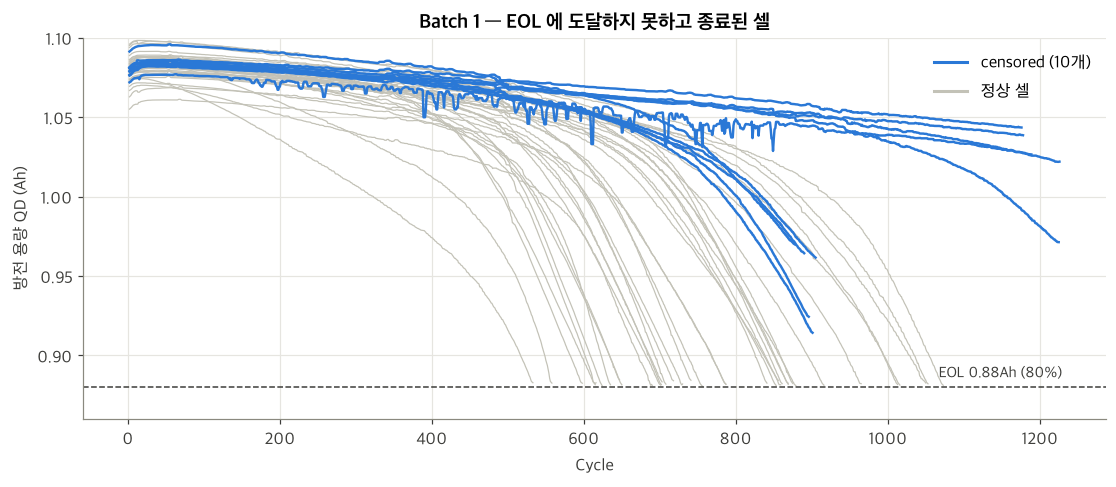

,cell_id,policy,cycle_life,n_cycles
0,b1c0,3.6C(80%)-3.6C,1190.0,1189
1,b1c1,3.6C(80%)-3.6C,1179.0,1178
2,b1c2,3.6C(80%)-3.6C,1177.0,1176
3,b1c3,4C(80%)-4C,1226.0,1225
4,b1c4,4C(80%)-4C,1227.0,1226
8,b1c8,5.4C(40%)-3.6C,879.0,878
10,b1c10,5.4C(50%)-3C,906.0,905
12,b1c12,5.4C(50%)-3.6C,902.0,901
13,b1c13,5.4C(50%)-3.6C,897.0,896
22,b1c22,6C(30%)-3.6C,891.0,890


In [3]:
def smooth(y, w=5):
    return pd.Series(y).rolling(w, center=True, min_periods=1).median().to_numpy()

fig, ax = plt.subplots(figsize=(12, 4.5))
b1 = cells_all[cells_all["batch"] == "b1"]
for _, c in b1.iterrows():
    g = summary_all[(summary_all["cell_id"] == c["cell_id"]) & (summary_all["cycle"] >= 2)]
    censored = c["exclude"] == "censored"
    ax.plot(g["cycle"], smooth(g["QD"]),
            color=BATCH_COLORS["b1"] if censored else "#c3c2b7",
            lw=1.6 if censored else 0.8, zorder=3 if censored else 2)
ax.axhline(EOL, color=TEXT, ls="--", lw=1)
ax.text(1230, EOL + 0.003, "EOL 0.88Ah (80%)", color=TEXT, ha="right", va="bottom", fontsize=10)
ax.plot([], [], color=BATCH_COLORS["b1"], label=f"censored ({(b1['exclude'] == 'censored').sum()}개)")
ax.plot([], [], color="#c3c2b7", label="정상 셀")
ax.set(ylim=(0.86, 1.10), xlabel="Cycle", ylabel="방전 용량 QD (Ah)",
       title="Batch 1 — EOL 에 도달하지 못하고 종료된 셀")
ax.legend(loc="upper right")
savefig(fig, "fig00_censored_cells")
plt.show()

cells_all.loc[cells_all["exclude"] == "censored", ["cell_id", "policy", "cycle_life", "n_cycles"]]

**[확인]**
- 파란 선 10개 셀은 마지막 측정 시점의 용량이 0.91 ~ 1.04Ah 로 **EOL(0.88Ah)보다 높은 상태에서 실험이 끝났다.**
- 이 셀들의 `cycle_life`(1177 ~ 1227 등)는 실제 수명이 아니라 **실험 종료 시점**이다 → 실제 수명은 이보다 길다 (우측 중도절단).
- 원논문에서도 이 셀들은 이어서 측정한 데이터와 합치거나 분석에서 제외했다. 현재 데이터에는 이어서 측정한 값이 없다. 실제 수명을 알 수 없는 셀을 학습에 넣으면 정답 자체가 틀린 데이터가 되기 때문에 **10개 모두 제외**했다.
- 제외하지 않으면 Batch 1 의 최대 수명이 1227 로 과대 표기되고, 해당 정책(`3.6C(80%)-3.6C`, `4C(80%)-4C`)이 "가장 긴 수명" 으로 잘못 해석될 수 있다고 생각한다.

### 0-2. 센서 이상값 확인

사용 셀에 대해 물리적으로 불가능한 범위를 벗어난 측정값 개수를 확인한다.

In [4]:
cells = cells_all[cells_all["exclude"] == ""].reset_index(drop=True)
summary = summary_all[summary_all["cell_id"].isin(cells["cell_id"])].reset_index(drop=True)

valid_range = pd.DataFrame(VALID_RANGE, index=["하한", "상한"])
outlier_cnt = pd.DataFrame({
    col: summary.groupby("batch")[col].apply(lambda x: (~x.between(lo, hi)).sum())
    for col, (lo, hi) in VALID_RANGE.items()
})
display(valid_range)
outlier_cnt

,QD,QC,IR,Tavg,Tmax,Tmin,chargetime
하한,0.8,0.8,1.000e-04,20,20,20,5
상한,1.2,1.2,5.000e-02,50,60,45,60


,QD,QC,IR,Tavg,Tmax,Tmin,chargetime
batch,,,,,,,
b1,37,65,46,36,36,36,41
b2,0,0,4445,0,0,23,10
b3,0,0,0,0,0,0,0


In [5]:
print("이상값 예시 (최소 / 최대)")
summary[list(VALID_RANGE)].agg(["min", "max"]).T

이상값 예시 (최소 / 최대)


,min,max
QD,0.0,2.884
QC,0.0,2.966
IR,0.0,0.023
Tavg,0.0,41.440
Tmax,0.0,44.663
Tmin,0.0,36.691
chargetime,0.0,3934.705


In [6]:
print("IR 전 구간이 0 인 셀:", summary.groupby("cell_id")["IR"].max().loc[lambda s: s == 0].index.tolist())

IR 전 구간이 0 인 셀: ['b2c41', 'b2c42', 'b2c43', 'b2c44', 'b2c45', 'b2c46']


**[확인]**
- QD 2.88Ah(정상 약 1.1Ah), QC 2.97Ah, 충전 시간 3,934분, Tmin 0°C 등 **센서 오류로 보이는 값**이 존재 (Batch 1 의 cycle 1 은 측정값이 0)
- Batch 2 의 6개 셀(`b2c41` ~ `b2c46`)은 **IR 이 전 구간 0** → 측정 자체가 되지 않았다
- 처리 : 스파이크가 열화 곡선과 피처 계산을 왜곡하지 않도록, 범위 밖 값은 NaN 으로 바꾸고 셀 내부에서 선형 보간했다 (`src.features.clean_summary`). IR 결측 셀은 0 을 그대로 쓰면 잘못된 값이 들어가기 때문에 모델링 단계에서 별도 처리가 필요할 것 같다

In [7]:
s = clean_summary(summary)
feat = build_features(cells, summary, curves)
feat["log_cl"] = np.log10(feat["cycle_life"])
print(f"사용 셀 : {len(cells)}개  (", cells["batch"].value_counts().sort_index().to_dict(), ")")

사용 셀 : 119개  ( {'b1': 36, 'b2': 39, 'b3': 44} )


---
## Q1. Cycle Life 분포는 어떻게 생겼는가?

In [8]:
def life_stats(x):
    return pd.Series({
        "n": len(x), "mean": x.mean(), "median": x.median(), "std": x.std(),
        "min": x.min(), "max": x.max(), "skew": x.skew(),
        "장수명(>1000) %": (x > 1000).mean() * 100,
        "단수명(<500) %": (x < 500).mean() * 100,
    })

life = cells.groupby("batch")["cycle_life"].apply(life_stats).unstack().round(1)
life

,n,mean,median,std,min,max,skew,장수명(>1000) %,단수명(<500) %
batch,,,,,,,,,
b1,36.0,788.4,772.5,148.7,534.0,1074.0,0.3,13.9,0.0
b2,39.0,565.7,472.0,222.2,392.0,1186.0,1.6,7.7,71.8
b3,44.0,1059.7,1005.5,313.9,541.0,1935.0,1.3,52.3,0.0


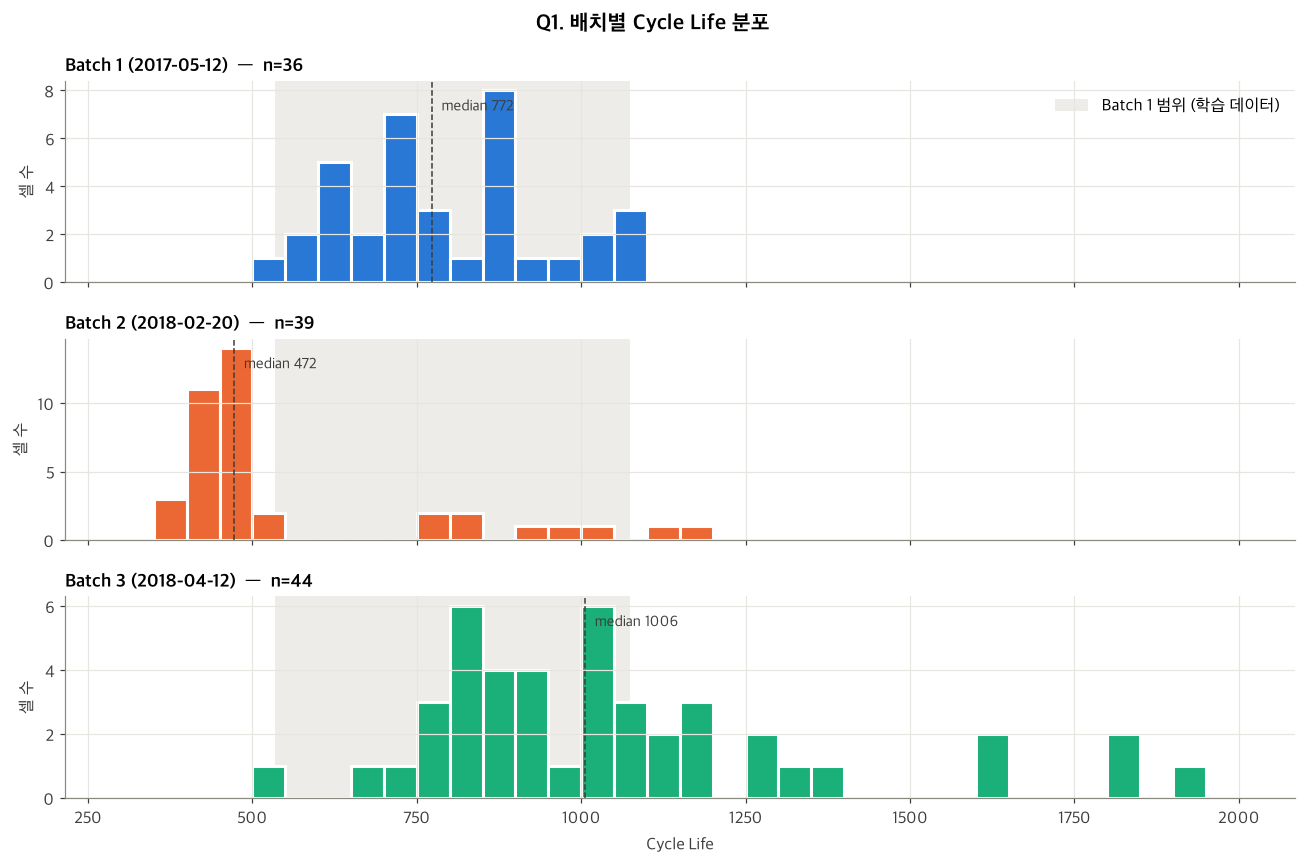

In [9]:
b1_min, b1_max = life.loc["b1", "min"], life.loc["b1", "max"]
bins = np.arange(300, 2001, 50)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, b in zip(axes, BATCHES):
    x = cells.loc[cells["batch"] == b, "cycle_life"]
    ax.axvspan(b1_min, b1_max, color=GRID, alpha=0.7, lw=0, label="Batch 1 범위 (학습 데이터)")
    ax.hist(x, bins=bins, color=BATCH_COLORS[b], edgecolor="white", linewidth=2)
    ax.axvline(x.median(), color=TEXT, ls="--", lw=1)
    ax.text(x.median() + 15, ax.get_ylim()[1] * 0.85, f"median {x.median():.0f}", color=TEXT, fontsize=10)
    ax.set_ylabel("셀 수")
    ax.set_title(f"{BATCH_LABELS[b]}  —  n={len(x)}", loc="left", fontsize=12)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Cycle Life")
fig.suptitle("Q1. 배치별 Cycle Life 분포", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig01_cycle_life_hist")
plt.show()

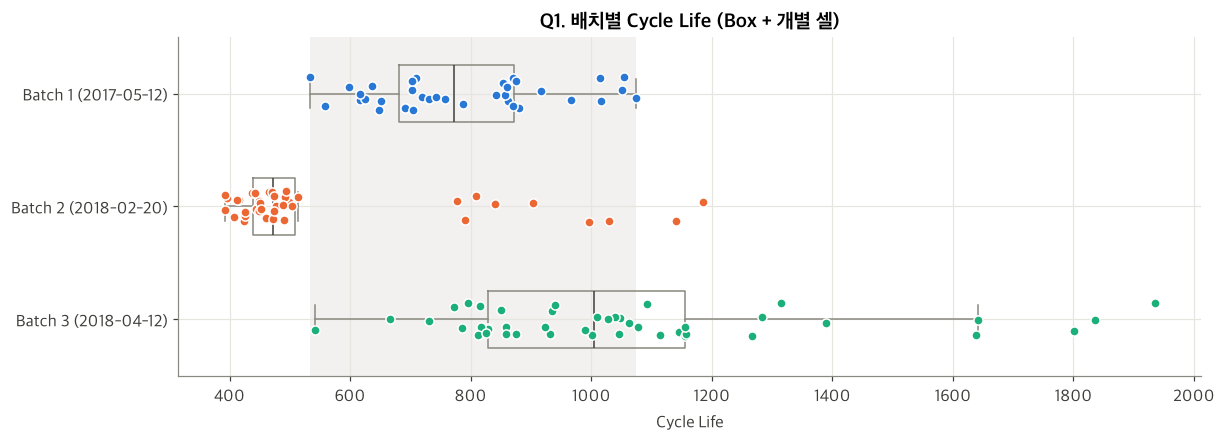

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
rng = np.random.default_rng(0)
for i, b in enumerate(BATCHES):
    x = cells.loc[cells["batch"] == b, "cycle_life"]
    ax.boxplot(x, positions=[i], vert=False, widths=0.5, showfliers=False,
               medianprops=dict(color=TEXT), boxprops=dict(color=MUTED), whiskerprops=dict(color=MUTED),
               capprops=dict(color=MUTED))
    ax.scatter(x, i + rng.uniform(-0.15, 0.15, len(x)), s=36, color=BATCH_COLORS[b],
               edgecolor="white", linewidth=1, zorder=3)
ax.axvspan(b1_min, b1_max, color=GRID, alpha=0.5, lw=0)
ax.set_yticks(range(3), [BATCH_LABELS[b] for b in BATCHES])
ax.invert_yaxis()
ax.set(xlabel="Cycle Life", title="Q1. 배치별 Cycle Life (Box + 개별 셀)")
savefig(fig, "fig02_cycle_life_box")
plt.show()

In [11]:
print("[Batch 2] newstructure 여부에 따른 수명")
display(cells[cells["batch"] == "b2"].groupby("newstructure")["cycle_life"].agg(["count", "mean", "min", "max"]))

print("[Batch 2] Batch 1 학습 범위(%d~%d)를 벗어나는 셀" % (b1_min, b1_max))
b2 = cells[cells["batch"] == "b2"]
print(f"  - 범위보다 짧음 : {(b2['cycle_life'] < b1_min).sum()}개 / {len(b2)}개")
print(f"  - 범위보다 김   : {(b2['cycle_life'] > b1_max).sum()}개 / {len(b2)}개")

[Batch 2] newstructure 여부에 따른 수명


,count,mean,min,max
newstructure,,,,
False,30,453.000,392.0,514.0
True,9,941.556,777.0,1186.0


[Batch 2] Batch 1 학습 범위(534~1074)를 벗어나는 셀
  - 범위보다 짧음 : 30개 / 39개
  - 범위보다 김   : 2개 / 39개


In [12]:
print("IQR(1.5) 기준 이상치 셀")
rows = []
for b, g in cells.groupby("batch"):
    q1, q3 = g["cycle_life"].quantile([0.25, 0.75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    o = g[(g["cycle_life"] < lo) | (g["cycle_life"] > hi)]
    rows.append(o.assign(range=f"{lo:.0f} ~ {hi:.0f}")[["batch", "cell_id", "policy", "cycle_life", "range"]])
pd.concat(rows)

IQR(1.5) 기준 이상치 셀


,batch,cell_id,policy,cycle_life,range
43,b2,b2c7,4.8C(80%)-4.8C-newstructure,777.0,336 ~ 612
44,b2,b2c8,5.2C(58%)-4C-newstructure,904.0,336 ~ 612
45,b2,b2c9,5.6C(26%)-4.5C-newstructure,791.0,336 ~ 612
66,b2,b2c32,4.8C(80%)-4.8C-newstructure,809.0,336 ~ 612
67,b2,b2c33,5.2C(58%)-4C-newstructure,1140.0,336 ~ 612
68,b2,b2c34,5.6C(26%)-4.5C-newstructure,1186.0,336 ~ 612
71,b2,b2c43,4.8C(80%)-4.8C-newstructure,1029.0,336 ~ 612
72,b2,b2c44,5.2C(58%)-4C-newstructure,841.0,336 ~ 612
73,b2,b2c45,5.6C(26%)-4.5C-newstructure,997.0,336 ~ 612
82,b3,b3c7,4.8C(80%)-4.8C-newstructure,1836.0,337 ~ 1646


In [13]:
print("배치별 가장 짧은 셀 3개")
short = cells.sort_values("cycle_life").groupby("batch").head(3).sort_values(["batch", "cycle_life"])
display(short[["batch", "cell_id", "policy", "cycle_life"]])


def high_rate_soc_frac(r, th=5.0):
    """0→80% 충전 구간 중 5C 이상으로 충전하는 SOC 비율"""
    q1 = min(r["Q1"], 80)
    return ((q1 if r["C1"] >= th else 0) + ((80 - q1) if r["C2"] >= th else 0)) / 80


hr = cells.assign(high_rate_frac=cells.apply(high_rate_soc_frac, axis=1))
print("5C 이상 고속 충전 SOC 비율 vs log10(cycle_life) 상관 :",
      {b: float(np.corrcoef(g["high_rate_frac"], np.log10(g["cycle_life"]))[0, 1].round(2)) for b, g in hr.groupby("batch")})

배치별 가장 짧은 셀 3개


,batch,cell_id,policy,cycle_life
11,b1,b1c20,5.4C(80%)-5.4C,534.0
12,b1,b1c21,5.4C(80%)-5.4C,559.0
35,b1,b1c45,8C(35%)-3.6C,599.0
55,b2,b2c19,6C(60%)-3C,392.0
42,b2,b2c6,3.6C(9%)-5C,393.0
51,b2,b2c15,3.6C(9%)-5C,396.0
102,b3,b3c28,3.7C(31%)-5.9C-newstructure,541.0
81,b3,b3c6,3.7C(31%)-5.9C-newstructure,667.0
105,b3,b3c31,5.9C(60%)-3.1C-newstructure,731.0


5C 이상 고속 충전 SOC 비율 vs log10(cycle_life) 상관 : {'b1': -0.31, 'b2': -0.2, 'b3': -0.34}


**[Q1 해석]**

[분포]
- **배치마다 분포가 크게 다르다.** 중앙값 Batch 1 **772** / Batch 2 **472** / Batch 3 **1006**
- Batch 1 : 534 ~ 1074, 왜도 0.3 → 비교적 대칭이며 범위가 좁다. 장수명(>1000) 14%, 단수명(<500) 0%
- Batch 2 : **두 개의 군집**. 일반 셀 30개는 392 ~ 514 에 몰려 있고(단수명 72%), `newstructure` 셀 9개만 777 ~ 1186 → 왜도 1.6
- Batch 3 : 541 ~ 1935, 왜도 1.3 → 오른쪽 꼬리가 길다. 장수명 52%. 전 셀이 `newstructure`

[이상치]
- IQR 기준 이상치는 Batch 2 의 `newstructure` 9개 전부, Batch 3 의 1,800 사이클 이상 3개
- 측정 오류가 아니라 **실험 조건(`newstructure`)이 다른 셀의 실제 수명**으로 보이기 때문에 제거하지 않았다
- `newstructure` : 충전 정책 이름에 붙은 표기로, 실험 진행 방식이 다른 셀이다. 원본 사이클 기록에서 사이클 안의 휴지(전류 0) 시간을 비교하면 newstructure 셀은 약 0.3분, Batch 2 일반 셀은 약 21분이다 (셀 제품은 모든 배치가 동일)
- 반대로 **배치별로 유독 짧은 셀**은 모두 높은 전류(5C 이상)로 넓은 충전 구간을 충전하는 정책이다 : Batch 1 `5.4C(80%)-5.4C` (534, 559), Batch 2 `3.6C(9%)-5C` · `6C(60%)-3C` (392 ~ 408), Batch 3 `3.7C(31%)-5.9C` (541 ~ 772, 이 정책의 3개 셀이 모두 하위권)
- 5C 이상으로 충전하는 구간 비율과 수명의 상관은 −0.31 / −0.20 / −0.34 로 약하지만 세 배치 모두 음수다 → 고속 충전을 오래 유지할수록 수명이 짧아지는 경향이 있는 것 같다 (Q4 에서 이어서 확인)

[to modeling]
- **Batch 2 의 39개 셀 중 30개(77%)가 Batch 1 의 최소 수명(534)보다 짧다** → 모델이 학습 때 보지 못한 범위를 예측해야 하는 외삽 문제가 될 것 같다
  - 트리 계열 모델은 학습 데이터 범위 밖의 값을 출력하지 못하기 때문에, 범위 밖도 예측할 수 있는 선형 계열 모델이 유리할 것 같다
- 오른쪽으로 긴 꼬리(왜도 > 1)를 펴고 평가 지표인 상대 오차(MAPE)와 기준을 맞추기 위해 **타깃을 log10(cycle_life) 로 변환**하기로 했다
- 학습 데이터인 Batch 1 이 36개뿐이라, 복잡한 모델은 과적합될 가능성이 높다고 생각한다

---
## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

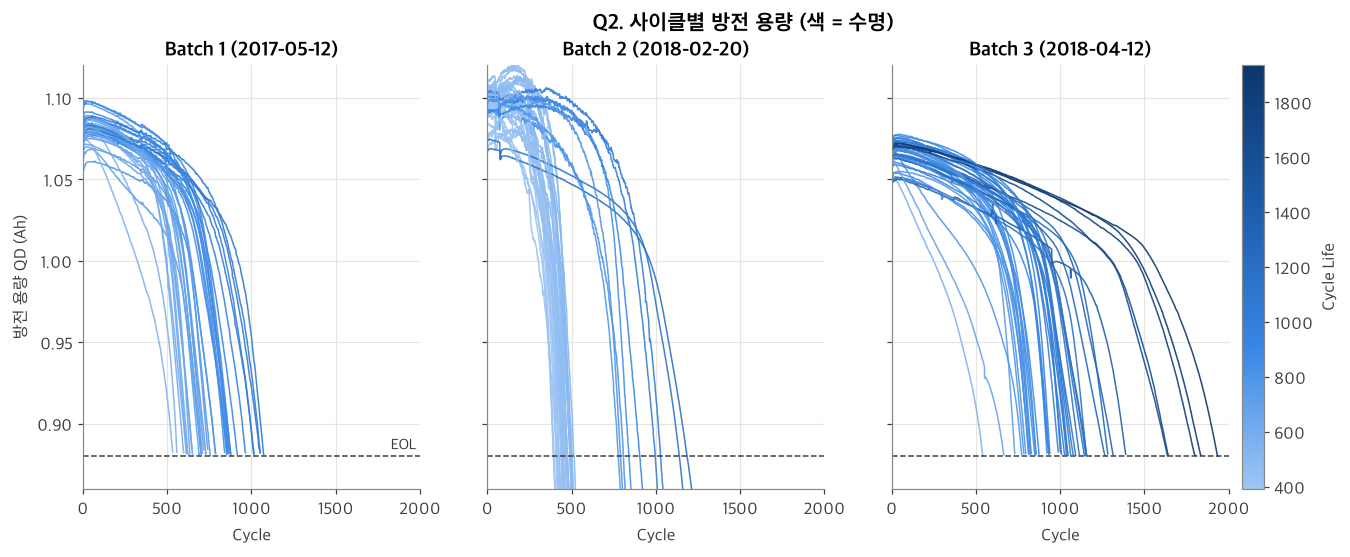

In [14]:
norm = Normalize(cells["cycle_life"].min(), cells["cycle_life"].max())
life_map = cells.set_index("cell_id")["cycle_life"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, b in zip(axes, BATCHES):
    sb = s[(s["batch"] == b) & (s["cycle"] >= 2)]
    for cid, g in sb.groupby("cell_id"):
        ax.plot(g["cycle"], smooth(g["QD"]), color=LIFE_CMAP(norm(life_map[cid])), lw=1, alpha=0.9)
    ax.axhline(EOL, color=TEXT, ls="--", lw=1)
    ax.set(title=BATCH_LABELS[b], xlabel="Cycle", xlim=(0, 2000))
axes[0].set(ylabel="방전 용량 QD (Ah)", ylim=(0.86, 1.12))
axes[0].text(1980, EOL + 0.004, "EOL", ha="right", color=TEXT, fontsize=10)
cb = fig.colorbar(ScalarMappable(norm, LIFE_CMAP), ax=axes, pad=0.01)
cb.set_label("Cycle Life")
fig.suptitle("Q2. 사이클별 방전 용량 (색 = 수명)", fontsize=14, fontweight="bold")
savefig(fig, "fig03_capacity_fade")
plt.show()

### Knee point

용량이 완만하게 줄다가 **급격히 떨어지기 시작하는 지점**. Kneedle 방식으로, cycle 2 ~ EOL 구간에서 **시작점과 EOL 을 잇는 직선으로부터 가장 멀리 위로 떨어진 점**을 knee 로 정의한다. (스파이크 영향을 줄이기 위해 15-사이클 rolling median 적용)

In [15]:
def find_knee(g):
    g = g[g["cycle"] >= 2]
    x = g["cycle"].to_numpy()
    y = pd.Series(g["QD"].to_numpy()).rolling(15, center=True, min_periods=1).median().to_numpy()
    end = np.argmax(y < EOL) if (y < EOL).any() else len(y) - 1
    x, y = x[: end + 1], y[: end + 1]
    xn = (x - x[0]) / (x[-1] - x[0])
    yn = (y - y[-1]) / (y[0] - y[-1])
    return x[np.argmax(yn - (1 - xn))]


def fade_rates(g):
    q = pd.Series(g.loc[g["cycle"] >= 2, "QD"].to_numpy()).rolling(15, center=True, min_periods=1).median().to_numpy()
    n = len(q)
    return pd.Series({
        "초기 열화율 (cycle 2→100)": (q[0] - q[min(98, n - 1)]) / 99 * 1000,
        "말기 열화율 (EOL 직전 100)": (q[max(n - 101, 0)] - q[n - 1]) / 100 * 1000,
    })


deg = pd.concat([
    s.groupby("cell_id").apply(find_knee).rename("knee"),
    s.groupby("cell_id").apply(fade_rates),
], axis=1).join(cells.set_index("cell_id")[["batch", "cycle_life"]])
deg["knee / cycle_life"] = deg["knee"] / deg["cycle_life"]

print("열화율 단위 : mAh / cycle")
deg.groupby("batch")[["knee", "knee / cycle_life", "초기 열화율 (cycle 2→100)", "말기 열화율 (EOL 직전 100)"]].median().round(3)

열화율 단위 : mAh / cycle


,knee,knee / cycle_life,초기 열화율 (cycle 2→100),말기 열화율 (EOL 직전 100)
batch,,,,
b1,550.0,0.709,0.003,0.913
b2,333.0,0.702,-0.010,1.765
b3,764.5,0.758,0.002,0.856


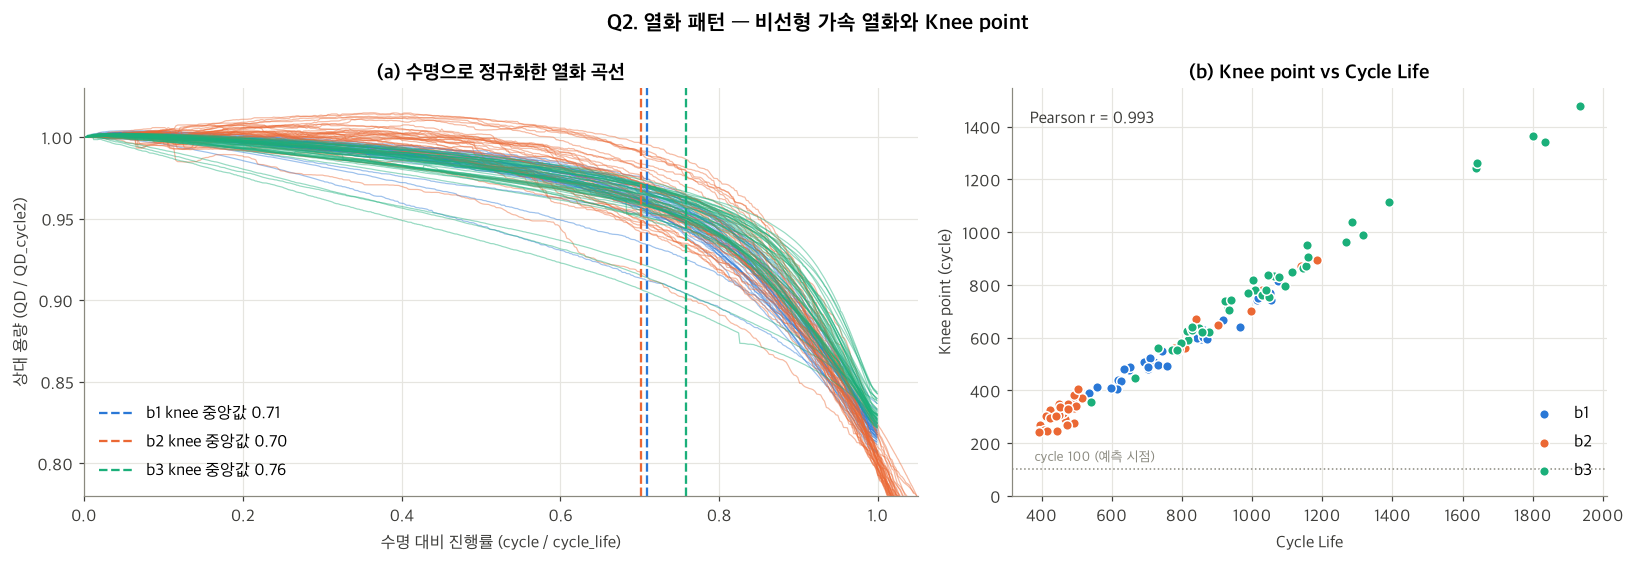

knee 가 cycle 100 이전에 나타난 셀 : 0 개


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw=dict(width_ratios=[1.4, 1]))

ax = axes[0]
for cid, g in s[s["cycle"] >= 2].groupby("cell_id"):
    b = cid[:2]
    q = smooth(g["QD"].to_numpy(), 15)
    ax.plot(g["cycle"] / life_map[cid], q / q[0], color=BATCH_COLORS[b], lw=0.8, alpha=0.45)
for b in BATCHES:
    kf = deg.loc[deg["batch"] == b, "knee / cycle_life"].median()
    ax.axvline(kf, color=BATCH_COLORS[b], ls="--", lw=1.5, label=f"{b} knee 중앙값 {kf:.2f}")
ax.set(xlim=(0, 1.05), ylim=(0.78, 1.03), xlabel="수명 대비 진행률 (cycle / cycle_life)",
       ylabel="상대 용량 (QD / QD_cycle2)", title="(a) 수명으로 정규화한 열화 곡선")
ax.legend(loc="lower left")

ax = axes[1]
for b in BATCHES:
    d = deg[deg["batch"] == b]
    ax.scatter(d["cycle_life"], d["knee"], s=40, color=BATCH_COLORS[b], edgecolor="white", lw=1, label=b, zorder=3)
r = np.corrcoef(deg["cycle_life"], deg["knee"])[0, 1]
ax.text(0.03, 0.95, f"Pearson r = {r:.3f}", transform=ax.transAxes, va="top", color=TEXT)
ax.axhline(100, color=MUTED, lw=1, ls=":")
ax.text(380, 115, "cycle 100 (예측 시점)", color=MUTED, fontsize=9, ha="left", va="bottom")
ax.set_ylim(0, None)
ax.set(xlabel="Cycle Life", ylabel="Knee point (cycle)", title="(b) Knee point vs Cycle Life")
ax.legend(loc="lower right")
fig.suptitle("Q2. 열화 패턴 — 비선형 가속 열화와 Knee point", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig04_knee_point")
plt.show()

print("knee 가 cycle 100 이전에 나타난 셀 :", (deg["knee"] <= 100).sum(), "개")

**[Q2 해석]**

[열화 패턴]
- 모든 배치에서 **완만한 감소 → 급격한 감소**의 2단계 비선형 열화 (선형 감소가 아니다)
- 열화 속도 (중앙값, mAh/cycle)
  - 초기 (cycle 2 → 100) : **0.00 ~ −0.01** → 사실상 감소 없음 (Batch 2 는 오히려 약간 증가)
  - 말기 (EOL 직전 100 사이클) : Batch 1 **0.91**, Batch 2 **1.77**, Batch 3 **0.86** → 수백 배 가속
- Batch 2 는 다른 배치보다 초기 용량이 높고(1.09 ~ 1.10Ah) 말기 열화가 2배 빠르다

[Knee point]
- 수명으로 정규화하면 세 배치의 곡선 모양이 거의 겹친다 → **knee 는 수명의 약 70 ~ 76% 지점** (Batch 1 0.71 / Batch 2 0.70 / Batch 3 0.76)
- knee 와 cycle_life 의 상관 r = 0.99 → knee 시점을 알면 수명도 거의 정해진다
- 하지만 **knee 가 cycle 100 이전에 나타난 셀은 0개** (가장 이른 knee 가 cycle 243)

[to modeling]
- 예측 시점(cycle 100)에서는 모든 셀이 아직 "완만한 구간"에 있기 때문에 **방전 용량 총량(QD)의 변화만으로는 장·단수명을 구분하기 어려울 것 같다**
- 같은 이유로 `qd_100_minus_2`, `fade_slope` 같은 용량 기반 피처는 신호가 약할 것이라 생각한다 → Q5 에서 확인
- 그래서 용량 총량이 아니라 **전압 구간별로 용량이 어떻게 변하는지** (ΔQ(V)) 를 봐야 차이가 드러날 것 같다 → Q3

---
## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

$\Delta Q_{100-10}(V) = Q_{100}(V) - Q_{10}(V)$ : 같은 전압에서 cycle 100 과 cycle 10 의 방전 용량 차이.
용량 총량(QD)은 초기 100 사이클 동안 거의 변하지 않지만, **전압 구간별로 어디서 용량이 빠지는지**는 셀마다 다를 수 있다.

In [17]:
V = curves["Vdlin"]
dq = {cid: delta_q(curves, cid) for cid in cells["cell_id"]}

print("[Notion 주의사항 확인] 배치별 Q_10(V) 시작/끝 값 (Ah)")
pd.DataFrame([
    {"batch": cid[:2], "Q10 @3.5V": curves["Qdlin"][curves["cell_id"].index(cid), 9][0],
     "Q10 @2.0V": curves["Qdlin"][curves["cell_id"].index(cid), 9][-1]}
    for cid in cells["cell_id"]
]).groupby("batch").agg(["mean", "std"]).round(4)

[Notion 주의사항 확인] 배치별 Q_10(V) 시작/끝 값 (Ah)


Q10 @3.5V            Q10 @2.0V       
            mean        std      mean    std
batch                                       
b1    -3.000e-04  1.000e-04     1.066  0.009
b2    -2.000e-04  1.000e-04     1.057  0.009
b3    -2.000e-04  1.000e-04     1.051  0.007

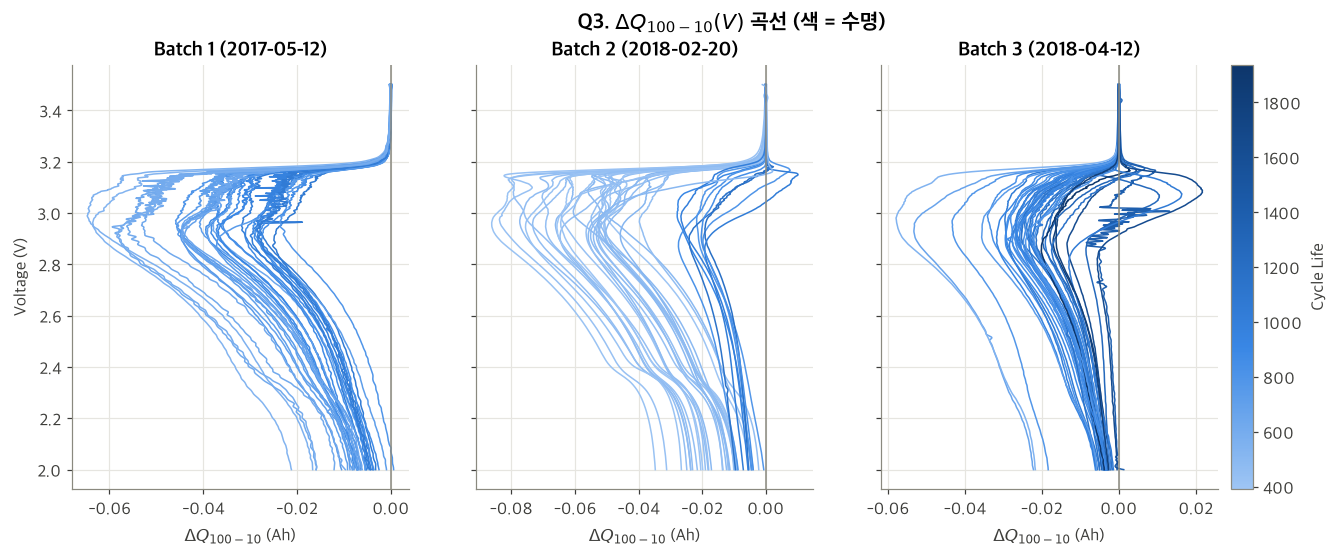

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, b in zip(axes, BATCHES):
    for cid in cells.loc[cells["batch"] == b, "cell_id"]:
        ax.plot(dq[cid], V, color=LIFE_CMAP(norm(life_map[cid])), lw=1)
    ax.axvline(0, color=MUTED, lw=1)
    ax.set(title=BATCH_LABELS[b], xlabel=r"$\Delta Q_{100-10}$ (Ah)")
axes[0].set_ylabel("Voltage (V)")
cb = fig.colorbar(ScalarMappable(norm, LIFE_CMAP), ax=axes, pad=0.01)
cb.set_label("Cycle Life")
fig.suptitle(r"Q3. $\Delta Q_{100-10}(V)$ 곡선 (색 = 수명)", fontsize=14, fontweight="bold")
savefig(fig, "fig05_delta_q_curves")
plt.show()

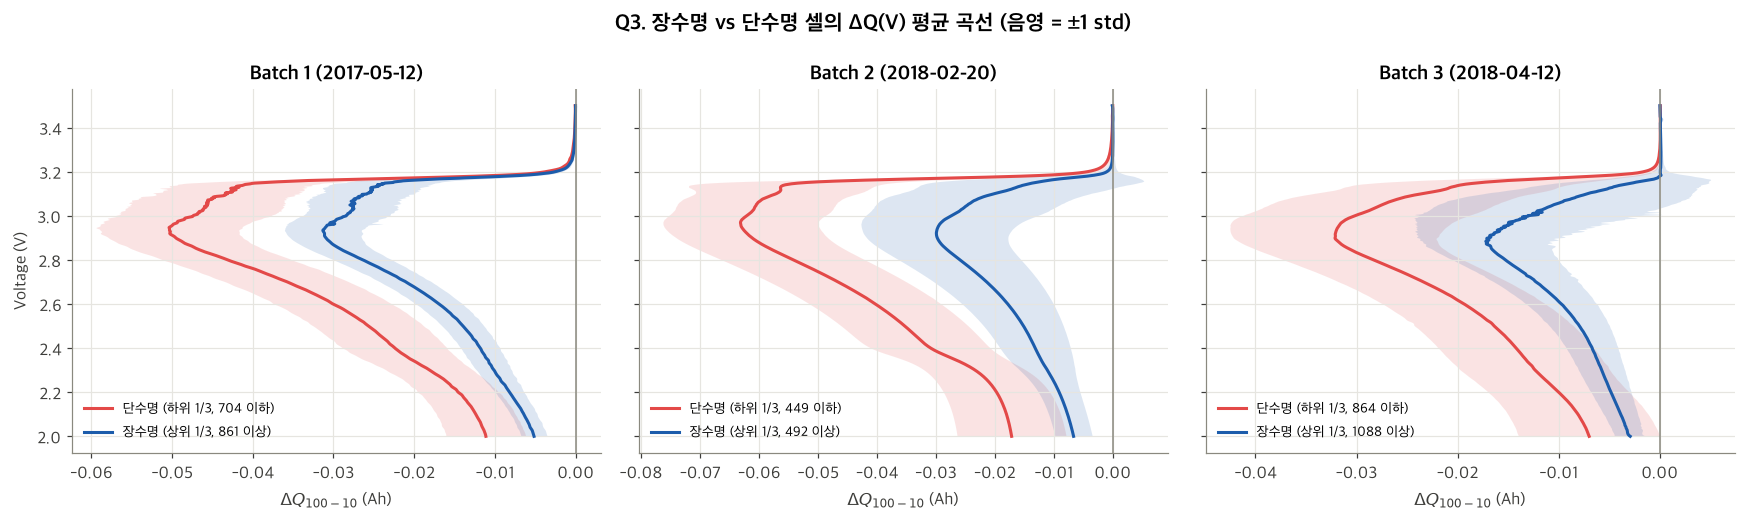

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, b in zip(axes, BATCHES):
    cb_ = cells[cells["batch"] == b]
    lo_q, hi_q = cb_["cycle_life"].quantile([1 / 3, 2 / 3])
    for name, mask, color in [
        (f"단수명 (하위 1/3, {lo_q:.0f} 이하)", cb_["cycle_life"] <= lo_q, "#e34948"),
        (f"장수명 (상위 1/3, {hi_q:.0f} 이상)", cb_["cycle_life"] >= hi_q, "#1c5cab"),
    ]:
        arr = np.stack([dq[c] for c in cb_.loc[mask, "cell_id"]])
        m, sd = arr.mean(0), arr.std(0)
        ax.fill_betweenx(V, m - sd, m + sd, color=color, alpha=0.15, lw=0)
        ax.plot(m, V, color=color, lw=2, label=name)
    ax.axvline(0, color=MUTED, lw=1)
    ax.set(title=BATCH_LABELS[b], xlabel=r"$\Delta Q_{100-10}$ (Ah)")
    ax.legend(loc="lower left", fontsize=9)
axes[0].set_ylabel("Voltage (V)")
fig.suptitle("Q3. 장수명 vs 단수명 셀의 ΔQ(V) 평균 곡선 (음영 = ±1 std)", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig06_delta_q_long_vs_short")
plt.show()

### ΔQ(V) 곡선 → 통계량 피처

곡선 하나(1,000 포인트)를 스칼라 피처로 요약한다. 값의 범위가 수십 배 차이 나므로 log10 을 취한다.

| 피처 | 정의 |
|---|---|
| `dq_var` | log10( Var(ΔQ) ) |
| `dq_min` | log10( \|min(ΔQ)\| ) |
| `dq_mean` | log10( \|mean(ΔQ)\| ) |
| `dq_skew` | log10( \|skewness(ΔQ)\| ) |
| `dq_kurt` | log10( \|kurtosis(ΔQ)\| ) |

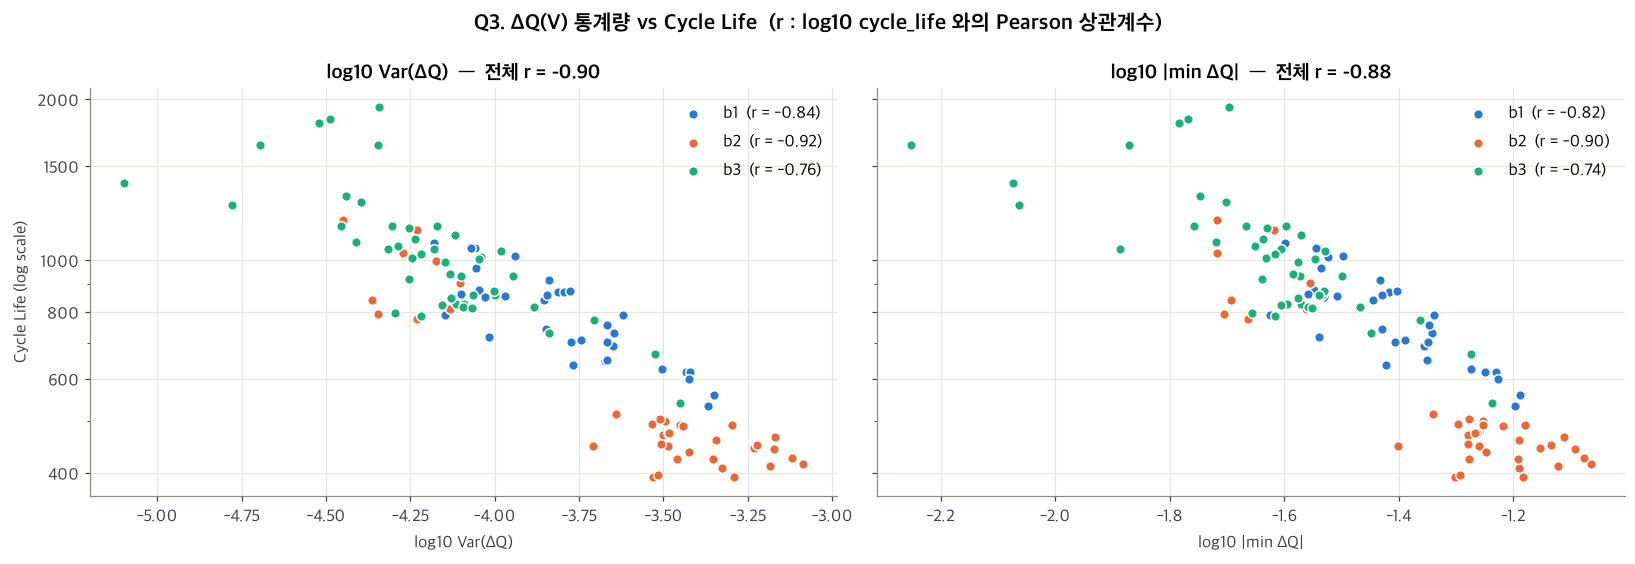

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, f, label in [(axes[0], "dq_var", "log10 Var(ΔQ)"), (axes[1], "dq_min", "log10 |min ΔQ|")]:
    for b in BATCHES:
        d = feat[feat["batch"] == b]
        r = np.corrcoef(d[f], d["log_cl"])[0, 1]
        ax.scatter(d[f], d["cycle_life"], s=40, color=BATCH_COLORS[b], edgecolor="white", lw=1,
                   label=f"{b}  (r = {r:.2f})", zorder=3)
    r_all = np.corrcoef(feat[f], feat["log_cl"])[0, 1]
    ax.set(xlabel=label, yscale="log", title=f"{label}  —  전체 r = {r_all:.2f}")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Cycle Life (log scale)")
axes[0].set_yticks([400, 600, 800, 1000, 1500, 2000], ["400", "600", "800", "1000", "1500", "2000"])
fig.suptitle("Q3. ΔQ(V) 통계량 vs Cycle Life  (r : log10 cycle_life 와의 Pearson 상관계수)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig07_delta_q_scatter")
plt.show()

In [21]:
dq_cols = ["dq_var", "dq_min", "dq_mean", "dq_skew", "dq_kurt"]
dq_corr = pd.DataFrame({b: g[dq_cols].corrwith(g["log_cl"]) for b, g in feat.groupby("batch")})
dq_corr["전체"] = feat[dq_cols].corrwith(feat["log_cl"])
print("log10(cycle_life) 와의 상관계수")
dq_corr.round(2)

log10(cycle_life) 와의 상관계수


,b1,b2,b3,전체
dq_var,-0.84,-0.92,-0.76,-0.90
dq_min,-0.82,-0.90,-0.74,-0.88
dq_mean,-0.77,-0.87,-0.65,-0.81
dq_skew,0.27,0.25,-0.02,0.22
dq_kurt,0.03,0.64,0.34,0.37


**[Q3 해석]**

[데이터 확인]
- Notion 주의사항(배치별 커브 시작점 차이) 확인 : `Qdlin` 은 세 배치 모두 3.5V 에서 0Ah 로 시작한다. ΔQ 는 같은 셀의 두 사이클을 빼는 값이라 셀 간 기준점 차이도 상쇄된다 → 이 피처에서는 왜곡이 없다고 판단했다

[ΔQ(V) 곡선]
- 대부분 셀이 음수(cycle 100 이 cycle 10 보다 용량이 작음)이며 **3.0V 부근에서 가장 크게 패인다**
- **색(수명)에 따라 곡선이 깔끔하게 층을 이룬다** : 단수명 셀일수록 더 깊고 넓게 패인다
- 장수명 vs 단수명 평균 곡선 : 세 배치 모두 단수명 셀의 곡선이 뚜렷하게 더 크다 (±1 std 음영이 거의 겹치지 않음)
- `newstructure` 장수명 셀(Batch 2 일부, Batch 3)은 3.0 ~ 3.1V 에서 **양수**(용량 증가)가 나타나기도 한다 → Batch 1 에는 없는 형태

[통계량 피처]
- log10 Var(ΔQ) 와 log10(cycle_life) 의 상관 : Batch 1 **−0.84**, Batch 2 **−0.92**, Batch 3 **−0.76**, 전체 **−0.90**
- `dq_min`, `dq_mean` 도 같은 방향으로 강하다. `dq_skew`, `dq_kurt` 는 약하고 배치마다 다르다
- 용량 총량(QD)은 거의 변하지 않았지만 ΔQ(V) 의 분산은 이미 수명 차이를 담고 있다 → **원논문의 핵심 결과가 세 배치 모두에서 재현됨**

[주의]
- 산점도에서 Batch 2 의 단수명 셀(주황, 400 ~ 500)은 Batch 1 추세선의 연장선보다 **아래**에 있다 → 같은 ΔQ 분산이라도 Batch 2 셀의 수명이 더 짧다 (배치 간 offset)
- Batch 1 만으로 `dq_var` 단일 회귀를 만들어 적용해 보면 MAPE 가 Batch 1 8% → Batch 2 일반 셀 32% 로 커진다 (탐색용 확인)

[to modeling]
- 세 배치 모두에서 수명과 강한 상관을 보이기 때문에 **`dq_var` 를 핵심 피처**로 사용하기로 했다. log 스케일에서 수명과 직선 관계라서, 선형 모델로 학습 범위 밖도 예측할 수 있을 것 같다
- 다만 `dq_var` 만으로는 배치 간 offset 을 설명하지 못하기 때문에, 이를 보정할 보조 피처가 필요할 것 같다 → Q5 에서 후보 탐색

---
## Q4. 충전 조건(C-rate)과 수명의 관계는?

충전 정책 `C1(Q1%)-C2` : 0 → Q1% 까지 C1 속도로, Q1% → 80% 까지 C2 속도로 충전 (80% 이후는 공통 1C CC-CV).
정책 문자열을 수치형 `C1`, `Q1`, `C2` 와, 정책상 0→80% 이론 충전 시간 `t80_policy` (분) 로 분해했다.

$t_{80} = 60 \times \left( \frac{Q_1}{C_1} + \frac{0.8 - Q_1}{C_2} \right)$

In [22]:
pol = (cells.groupby(["batch", "policy"])["cycle_life"].agg(["count", "mean", "std", "min", "max"])
       .join(feat.groupby(["batch", "policy"])["t80_policy"].first()).round(1))
print("배치별 정책 수 :", cells.groupby("batch")["policy"].nunique().to_dict())
pol.sort_values(["batch", "mean"], ascending=[True, False])

배치별 정책 수 : {'b1': 20, 'b2': 12, 'b3': 8}


count    mean    std     min     max  \
batch policy                                                              
b1    4.4C(80%)-4.4C                   1  1074.0    NaN  1074.0  1074.0   
      5.4C(40%)-3.6C                   1  1054.0    NaN  1054.0  1054.0   
      6C(30%)-3.6C                     1  1014.0    NaN  1014.0  1014.0   
      8C(15%)-3.6C                     2  1008.5   60.1   966.0  1051.0   
      6C(40%)-3C                       2   935.5  115.3   854.0  1017.0   
      6C(50%)-3C                       2   888.5   40.3   860.0   917.0   
      5.4C(60%)-3.6C                   2   859.5    3.5   857.0   862.0   
      6C(40%)-3.6C                     2   856.0   19.8   842.0   870.0   
      5.4C(60%)-3C                     2   799.5  113.8   719.0   880.0   
      6C(50%)-3.6C                     2   792.5  118.1   709.0   876.0   
      5.4C(50%)-3C                     1   788.0    NaN   788.0   788.0   
      4.8C(80%)-4.8C                   2   753.0  165.5   636.0   870.0   
      6C(60%)-3C                       2   744.0   18.4   731.0   757.0   
      5.4C(70%)-3C                     2   739.5   68.6   691.0   788.0   
      7C(30%)-3.6C                     2   722.5   27.6   703.0   742.0   
      8C(25%)-3.6C                     2   676.5   36.1   651.0   702.0   
      7C(40%)-3C                       2   676.0   39.6   648.0   704.0   
      7C(40%)-3.6C                     2   621.0    5.7   617.0   625.0   
      8C(35%)-3.6C                     2   607.5   12.0   599.0   616.0   
      5.4C(80%)-5.4C                   2   546.5   17.7   534.0   559.0   
b2    5.6C(26%)-4.5C-newstructure      3   991.3  197.6   791.0  1186.0   
      5.2C(58%)-4C-newstructure        3   961.7  157.6   841.0  1140.0   
      4.8C(80%)-4.8C-newstructure      3   871.7  137.2   777.0  1029.0   
      4.8C(80%)-4.8C                   5   483.6   30.3   437.0   514.0   
      4.65C(44%)-5C                    2   482.5   23.3   466.0   499.0   
      5.2C(58%)-4C                     4   477.8   18.5   452.0   493.0   
      5.2C(50%)-4.25C                  5   454.0   20.9   424.0   474.0   
      4.65C(69%)-6C                    2   452.0   11.3   444.0   460.0   
      5.6C(26%)-4.5C                   6   448.5   29.1   412.0   491.0   
      3.6C(30%)-6C                     2   421.0    7.1   416.0   426.0   
      6C(60%)-3C                       2   400.0   11.3   392.0   408.0   
      3.6C(9%)-5C                      2   394.5    2.1   393.0   396.0   
b3    4.8C(80%)-4.8C-newstructure      6  1564.2  285.7  1078.0  1836.0   
      5C(67%)-4C-newstructure          7  1105.7  402.9   813.0  1935.0   
      5.3C(54%)-4C-newstructure        8  1074.4  129.7   935.0  1315.0   
      5.6C(19%)-4.6C-newstructure      8  1001.4  174.6   796.0  1267.0   
      5.6C(36%)-4.3C-newstructure      8   930.9  135.0   786.0  1155.0   
      5.9C(15%)-4.6C-newstructure      2   867.0   12.7   858.0   876.0   
      5.9C(60%)-3.1C-newstructure      2   866.5  191.6   731.0  1002.0   
      3.7C(31%)-5.9C-newstructure      3   660.0  115.7   541.0   772.0   

                                   t80_policy  
batch policy                                   
b1    4.4C(80%)-4.4C                     10.9  
      5.4C(40%)-3.6C                     11.1  
      6C(30%)-3.6C                       11.3  
      8C(15%)-3.6C                       12.0  
      6C(40%)-3C                         12.0  
      6C(50%)-3C                         11.0  
      5.4C(60%)-3.6C                     10.0  
      6C(40%)-3.6C                       10.7  
      5.4C(60%)-3C                       10.7  
      6C(50%)-3.6C                       10.0  
      5.4C(50%)-3C                       11.6  
      4.8C(80%)-4.8C                     10.0  
      6C(60%)-3C                         10.0  
      5.4C(70%)-3C                        9.8  
      7C(30%)-3.6C                       10.9  
      8C(25%)-3.6C                       11.0  
      7C(40%)-3C    

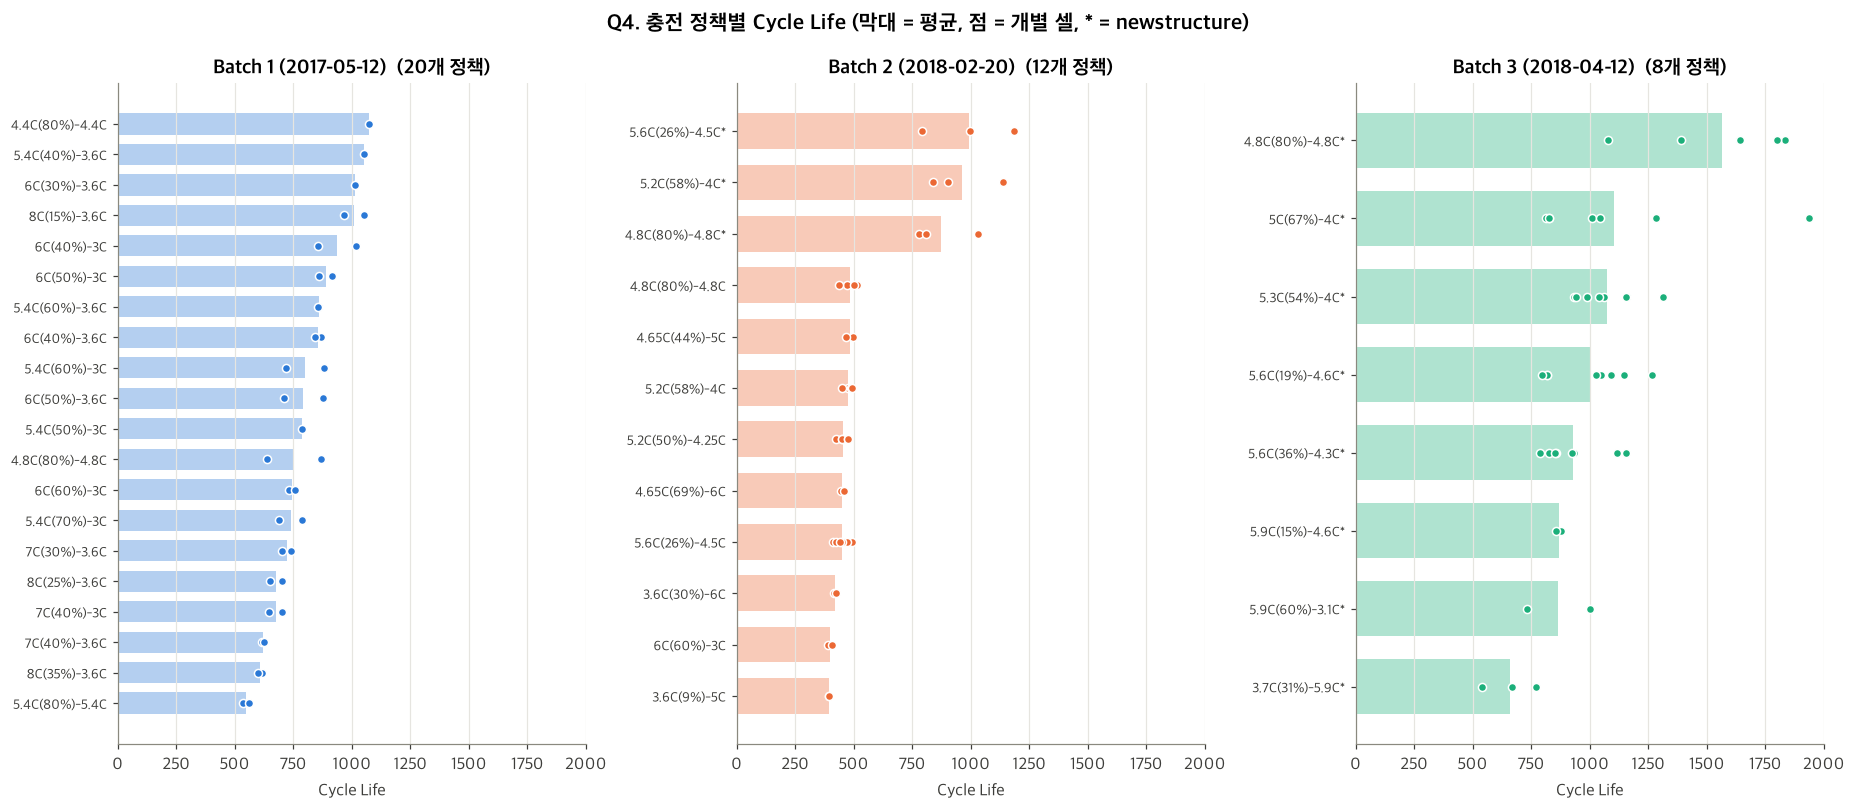

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7.5), gridspec_kw=dict(width_ratios=[1, 1, 1]))
for ax, b in zip(axes, BATCHES):
    d = cells[cells["batch"] == b]
    order = d.groupby("policy")["cycle_life"].mean().sort_values()
    ypos = {p: i for i, p in enumerate(order.index)}
    ax.barh(range(len(order)), order.values, color=BATCH_COLORS[b], alpha=0.35, height=0.7)
    ax.scatter(d["cycle_life"], d["policy"].map(ypos), s=28, color=BATCH_COLORS[b], edgecolor="white", lw=1, zorder=3)
    ax.set_yticks(range(len(order)), [p.replace("-newstructure", "*") for p in order.index], fontsize=9)
    ax.set(title=f"{BATCH_LABELS[b]}  ({len(order)}개 정책)", xlabel="Cycle Life", xlim=(0, 2000))
    ax.grid(axis="y", visible=False)
fig.suptitle("Q4. 충전 정책별 Cycle Life (막대 = 평균, 점 = 개별 셀, * = newstructure)", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig08_policy_life")
plt.show()

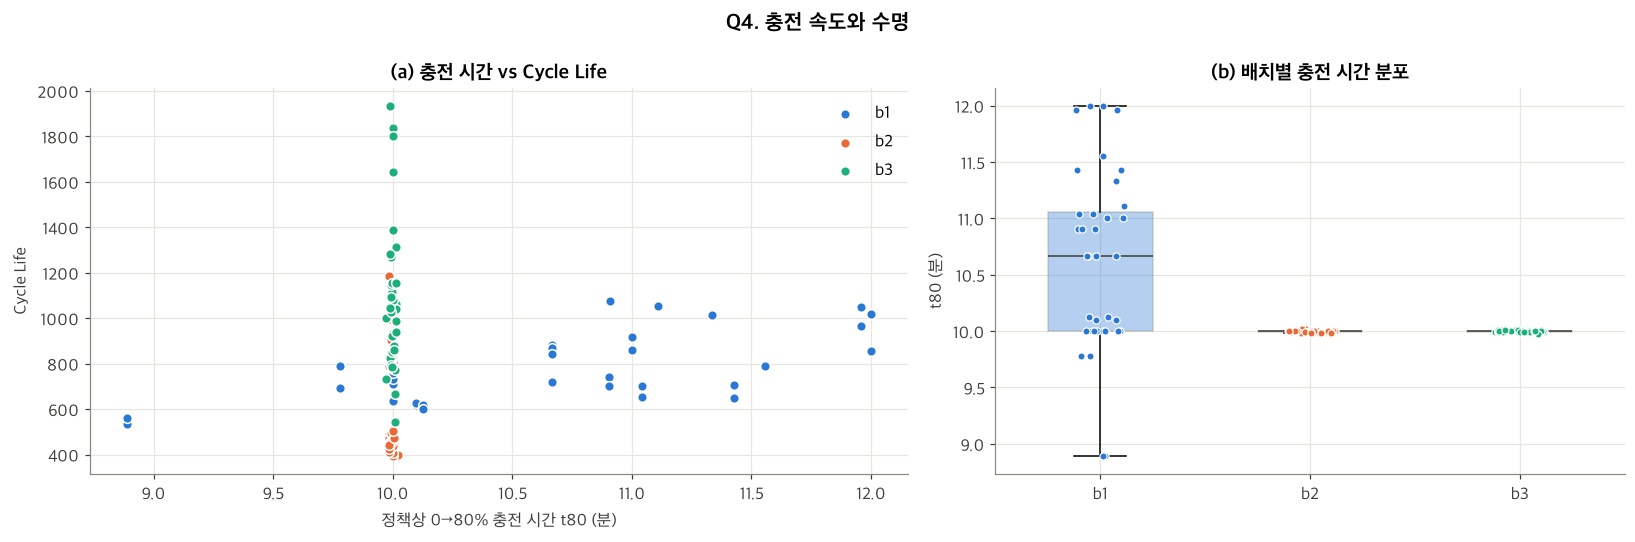

t80_policy                    chargetime_2_6                    
            mean   std   min    max           mean   std    min    max
batch                                                                 
b1         10.61  0.81  8.89  12.00          10.74  0.81   8.96  12.15
b2         10.00  0.01  9.99  10.02          10.15  0.06  10.04  10.22
b3         10.00  0.01  9.97  10.01          10.18  0.35  10.04  11.05

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw=dict(width_ratios=[1.3, 1]))

ax = axes[0]
for b in BATCHES:
    d = feat[feat["batch"] == b]
    ax.scatter(d["t80_policy"], d["cycle_life"], s=40, color=BATCH_COLORS[b], edgecolor="white", lw=1, label=b, zorder=3)
ax.set(xlabel="정책상 0→80% 충전 시간 t80 (분)", ylabel="Cycle Life", title="(a) 충전 시간 vs Cycle Life")
ax.legend()

ax = axes[1]
data = [feat.loc[feat["batch"] == b, "t80_policy"] for b in BATCHES]
bp = ax.boxplot(data, widths=0.5, patch_artist=True, showfliers=False, medianprops=dict(color=TEXT))
for patch, b in zip(bp["boxes"], BATCHES):
    patch.set(facecolor=BATCH_COLORS[b], alpha=0.35, edgecolor=MUTED)
for i, (b, x) in enumerate(zip(BATCHES, data), 1):
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(x)), x, s=22, color=BATCH_COLORS[b], edgecolor="white", lw=0.8, zorder=3)
ax.set_xticks([1, 2, 3], BATCHES)
ax.set(ylabel="t80 (분)", title="(b) 배치별 충전 시간 분포")
fig.suptitle("Q4. 충전 속도와 수명", fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig09_charge_time")
plt.show()

feat.groupby("batch")[["t80_policy", "chargetime_2_6"]].agg(["mean", "std", "min", "max"]).round(2)

In [25]:
rate_cols = ["C1", "Q1", "C2", "t80_policy", "chargetime_2_6"]
rate_corr = pd.DataFrame({b: g[rate_cols].corrwith(g["log_cl"]) for b, g in feat.groupby("batch")})
print("log10(cycle_life) 와의 상관계수")
rate_corr.round(2)

log10(cycle_life) 와의 상관계수


,b1,b2,b3
C1,-0.24,0.20,0.02
Q1,-0.18,0.16,0.52
C2,-0.29,-0.11,-0.13
t80_policy,0.59,-0.35,0.02
chargetime_2_6,0.57,-0.94,0.60


In [26]:
# 열화 속도 : 수명 동안 사이클당 평균 용량 감소량 (mAh/cycle) — 수명을 사용하므로 EDA 확인용 (피처 아님)
fade_rate = (feat["qd_2"] - EOL) / feat["cycle_life"] * 1000
display(fade_rate.groupby(feat["batch"]).agg(["mean", "min", "max"]).round(3).rename_axis("열화 속도 (mAh/cycle)"))

fr = pd.DataFrame({b: g[rate_cols[:4]].corrwith(fade_rate[g.index]) for b, g in feat.groupby("batch")})
print("충전 조건과 열화 속도의 상관계수")
fr.round(2)

,mean,min,max
열화 속도 (mAh/cycle),,,
b1,0.260,0.183,0.362
b2,0.419,0.158,0.536
b3,0.186,0.098,0.318


충전 조건과 열화 속도의 상관계수


,b1,b2,b3
C1,0.26,-0.14,-0.11
Q1,0.19,-0.18,-0.51
C2,0.40,0.08,0.21
t80_policy,-0.65,0.28,-0.01


**[Q4 해석]**

[정책별 수명]
- Batch 1 (20개 정책) : 대체로 **C-rate 가 높을수록 수명이 짧다**. 최장 `4.4C(80%)-4.4C` 1074 vs 최단 `5.4C(80%)-5.4C` 547
  - 다만 같은 1단계 C-rate 에서도 전환 지점(Q1)에 따라 차이가 커서 (`8C(15%)` 1009 vs `8C(35%)` 608), 단순히 "빠를수록 짧다" 로 끝나지 않는다
  - 정책당 셀이 1 ~ 2개뿐이라 경향 수준의 해석
- Batch 2 : **같은 정책이라도 `newstructure` 셀의 수명이 약 2배** (`4.8C(80%)-4.8C` : 일반 ~490 vs newstructure ~870) → 이 배치에서는 충전 정책보다 **실험 조건(휴지 시간)** 의 영향이 더 큰 것 같다 (newstructure 휴지 약 0.3분 vs 일반 약 21분)
- Batch 3 : 8개 정책 모두 newstructure. 같은 정책 안에서도 편차가 크다 (`5C(67%)-4C` : 813 ~ 1935)

[충전 속도]
- Batch 1 은 0→80% 충전 시간이 **8.9 ~ 12.0분**으로 다양하고, 충전 시간이 길수록(느린 충전) 수명이 길다 (r = 0.59)
- **Batch 2 · 3 은 모든 정책이 정확히 10분 충전**으로 설계됨 (표준편차 0.01분) → 충전 속도 자체는 같고, 10분 안에서 전류를 어떻게 나누는지만 다르다
- 그 결과 충전 시간과 수명의 상관이 배치마다 뒤집힌다 : Batch 1 +0.59 / Batch 2 −0.35 / Batch 3 +0.02
- 충전 패턴과 **열화 속도**(수명 동안 사이클당 평균 용량 감소)의 상관 : Batch 1 은 충전 시간과 r = −0.65 로, 빨리 충전할수록 열화가 빠르다. Batch 2·3 은 −0.01 ~ +0.28 로 약하고 방향도 다르다

[to modeling]
- 충전 시간(`t80_policy`, `chargetime_2_6`) 은 Batch 2 에서 값이 거의 상수라 **Batch 1 안에서만 유효한 신호**로 보인다. 그래서 Batch 2 예측에는 도움이 되지 않고, 오히려 Batch 1 에 과적합될 위험이 있다고 생각한다
- `C1`, `Q1`, `C2` 도 배치마다 부호가 바뀌기 때문에, 정책 변수는 **피처에서 제외**하기로 했다
- 충전 조건의 영향은 결국 전극 열화로 나타나고 그 결과가 ΔQ(V) 에 반영되기 때문에, 정책 변수를 빼도 ΔQ 로 간접 반영될 것이라 생각한다

---
## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

초기 100 사이클 이내 정보로 만든 23개 후보 피처(`src/features.py`)와 log10(cycle_life) 의 상관을 **배치별로** 비교한다.
배치별로 보는 이유 : 학습(Batch 1) → 평가(Batch 2) 구조에서는 **배치가 바뀌어도 관계가 유지되는 피처**만 일반화된다.

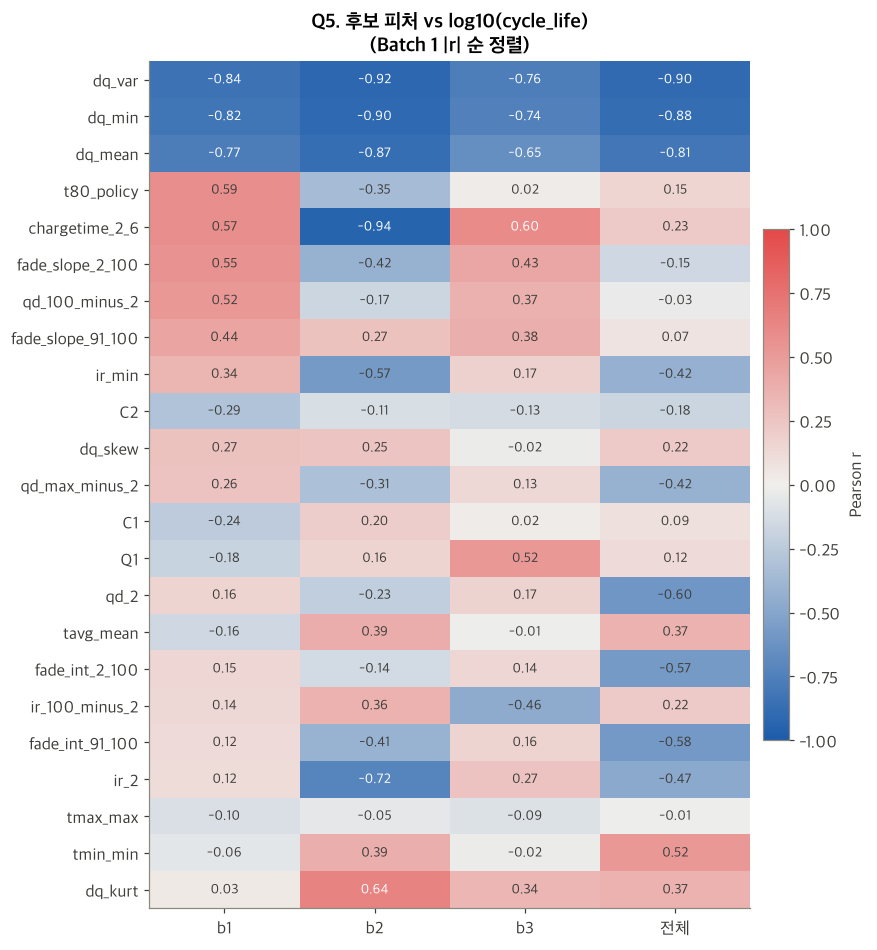

In [27]:
from src.features import FEATURE_COLS

corr = pd.DataFrame({b: g[FEATURE_COLS].corrwith(g["log_cl"]) for b, g in feat.groupby("batch")})
corr["전체"] = feat[FEATURE_COLS].corrwith(feat["log_cl"])
corr = corr.loc[corr["b1"].abs().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7.5, 10))
im = ax.imshow(corr.values, cmap=CORR_CMAP, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(corr.shape[1]), corr.columns)
ax.set_yticks(range(corr.shape[0]), corr.index)
ax.grid(False)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else TEXT)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Pearson r")
ax.set_title("Q5. 후보 피처 vs log10(cycle_life)\n(Batch 1 |r| 순 정렬)", fontsize=13)
savefig(fig, "fig10_feature_corr")
plt.show()

In [28]:
sign_consistent = (np.sign(corr[BATCHES]).nunique(axis=1) == 1)
summary_corr = pd.DataFrame({
    "b1 r": corr["b1"], "b2 r": corr["b2"], "b3 r": corr["b3"],
    "부호 일관": sign_consistent,
    "최소 |r|": corr[BATCHES].abs().min(axis=1),
}).sort_values("최소 |r|", ascending=False)
print("세 배치에서 부호가 같고 |r| 이 큰 순서")
summary_corr.round(2).head(12)

세 배치에서 부호가 같고 |r| 이 큰 순서


,b1 r,b2 r,b3 r,부호 일관,최소 |r|
dq_var,-0.84,-0.92,-0.76,True,0.76
dq_min,-0.82,-0.90,-0.74,True,0.74
dq_mean,-0.77,-0.87,-0.65,True,0.65
chargetime_2_6,0.57,-0.94,0.60,False,0.57
fade_slope_2_100,0.55,-0.42,0.43,False,0.42
fade_slope_91_100,0.44,0.27,0.38,True,0.27
ir_min,0.34,-0.57,0.17,False,0.17
qd_100_minus_2,0.52,-0.17,0.37,False,0.17
Q1,-0.18,0.16,0.52,False,0.16
qd_2,0.16,-0.23,0.17,False,0.16


### 다중공선성 확인

Batch 1 에서 수명과 상관이 있는 피처들끼리의 상관과 VIF(Variance Inflation Factor)를 확인한다.

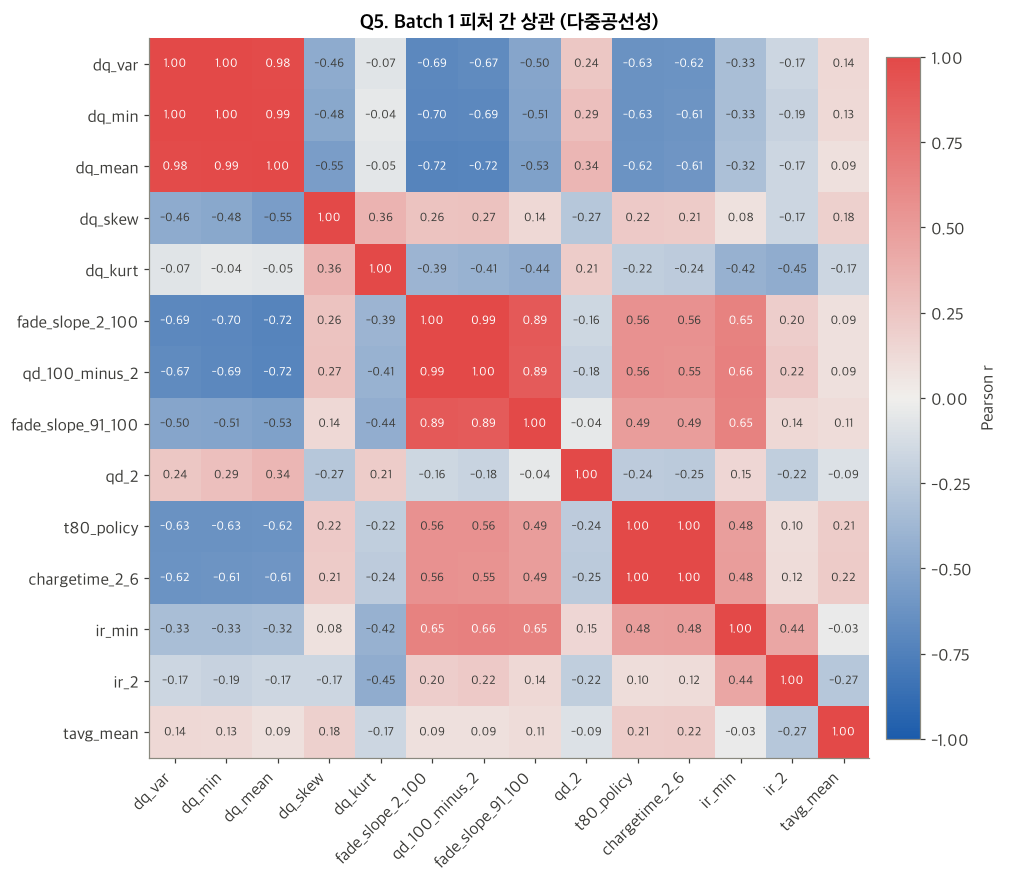

In [29]:
cand = ["dq_var", "dq_min", "dq_mean", "dq_skew", "dq_kurt", "fade_slope_2_100", "qd_100_minus_2",
        "fade_slope_91_100", "qd_2", "t80_policy", "chargetime_2_6", "ir_min", "ir_2", "tavg_mean"]
b1f = feat.loc[feat["batch"] == "b1", cand]
cc = b1f.corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(cc.values, cmap=CORR_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(cand)), cand, rotation=45, ha="right")
ax.set_yticks(range(len(cand)), cand)
ax.grid(False)
for i in range(len(cand)):
    for j in range(len(cand)):
        v = cc.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else TEXT)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Pearson r")
ax.set_title("Q5. Batch 1 피처 간 상관 (다중공선성)")
savefig(fig, "fig11_multicollinearity")
plt.show()

In [30]:
def vif(df):
    out = {}
    for col in df.columns:
        X, y = df.drop(columns=col), df[col]
        r2 = LinearRegression().fit(X, y).score(X, y)
        out[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out, name="VIF")

vif_all = vif(b1f.dropna())
vif_dq = vif(b1f[["dq_var", "dq_min", "dq_mean"]])
display(vif_all.round(1).sort_values(ascending=False).to_frame("VIF (14개 전체)"))
vif_dq.round(1).to_frame("VIF (ΔQ 3개)")

,VIF (14개 전체)
chargetime_2_6,1343.9
t80_policy,1329.3
dq_min,920.4
dq_var,560.2
dq_mean,274.9
qd_100_minus_2,189.4
fade_slope_2_100,161.8
fade_slope_91_100,7.4
ir_min,7.0
dq_skew,4.9


,VIF (ΔQ 3개)
dq_var,208.5
dq_min,415.3
dq_mean,72.3


**[Q5 해석]**

[수명과의 상관]
- **세 배치에서 부호가 같고 강한 피처는 ΔQ 계열 3개뿐** : `dq_var` (최소 |r| 0.76), `dq_min` (0.74), `dq_mean` (0.65)
- Batch 1 에서 상위였던 `t80_policy`, `chargetime_2_6`, `fade_slope_2_100`, `qd_100_minus_2` 는 **Batch 2 에서 부호가 뒤집힌다** → Batch 1 에서만 보이는 관계
- `fade_slope_91_100` 은 부호는 일관되지만 약하다 (0.27 ~ 0.44)
- IR, 온도 계열은 배치마다 방향이 다르다. IR 은 Batch 2 에 결측 셀 6개도 있다
- "전체" 열에서 `qd_2`(−0.60), `fade_int`(−0.57) 가 강해 보이지만 배치 안에서는 약하다 → 배치 간 평균 차이(Batch 2 는 초기 용량이 높고 수명이 짧음)가 만든 **허상 상관**으로 보인다

[다중공선성]
- `dq_var` · `dq_min` · `dq_mean` 끼리 상관이 매우 높다 (VIF 72 ~ 415) → 같은 정보를 반복
- `t80_policy` ↔ `chargetime_2_6` (VIF 1,300+) : 정책상 시간과 실측 시간이라 사실상 같은 변수
- `fade_slope_2_100` ↔ `qd_100_minus_2` (VIF 160 ~ 190) : 둘 다 "100 사이클 동안 줄어든 용량"

[to modeling]
- ΔQ 피처끼리 같은 정보를 반복하기 때문에, 피처 수를 적게 유지하고 대표 피처(`dq_var`) 위주로 쓰거나 **규제(Ridge / ElasticNet)** 로 공선성을 처리하려고 한다
- 학습(Batch 1)과 평가(Batch 2)의 배치가 다르기 때문에, "Batch 1 에서 상관이 높은 피처" 가 아니라 **"배치가 바뀌어도 관계가 유지되는 피처"** 를 기준으로 선택하기로 했다

### Q5-1. EDA 기반 파생변수 검증

앞의 EDA 에서 발견한 내용을 바탕으로 파생변수를 직접 만들어, 기존 `dq_var` 에 없는 정보가 있는지 확인한다. (`src.features.derived_dq_features`)

| 파생변수 | 정의 | 만든 이유 |
|---|---|---|
| `dq_area_29_31` | log10 \| 2.9 ~ 3.1V 구간 ΔQ 합 \| | Q3 : 3.0V 부근에서 가장 크게 패임 |
| `dq_lowv_mean` | log10 \| 2.0 ~ 2.7V 구간 ΔQ 평균 \| | Q3 : 저전압 구간에서도 수명별로 곡선이 벌어짐 |
| `dq_var_norm` | log10 Var( ΔQ / cycle 10 방전 용량 ) | Q5 : Batch 2 는 초기 용량이 높음 → 용량 차이 보정 시도 |
| `dq_var_100_20` | log10 Var( Q100 − Q20 ) | 기준 사이클을 바꿔도 같은 신호인지 |
| `dq_var_50_10` | log10 Var( Q50 − Q10 ) | 더 이른 시점(50 사이클)에도 예측이 가능한지 |
| `dq_v_at_min` | ΔQ 가 가장 깊이 패인 전압 | 패이는 위치가 수명과 관련 있는지 |

In [31]:
from src.features import DERIVED_COLS

cols = DERIVED_COLS + ["dq_var"]
b1 = feat[feat["batch"] == "b1"]
der = pd.DataFrame({b: g[cols].corrwith(g["log_cl"]) for b, g in feat.groupby("batch")})
der["dq_var 와의 상관 (b1)"] = b1[cols].corrwith(b1["dq_var"])
print("log10(cycle_life) 와의 상관계수  (마지막 열 : 기존 dq_var 와 얼마나 겹치는지)")
der.round(2)

log10(cycle_life) 와의 상관계수  (마지막 열 : 기존 dq_var 와 얼마나 겹치는지)


,b1,b2,b3,dq_var 와의 상관 (b1)
dq_area_29_31,-0.81,-0.88,-0.53,0.99
dq_lowv_mean,-0.68,-0.78,-0.69,0.92
dq_var_norm,-0.85,-0.92,-0.77,1.00
dq_var_100_20,-0.84,-0.90,-0.78,0.98
dq_var_50_10,-0.75,-0.61,-0.59,0.93
dq_v_at_min,-0.01,-0.34,-0.15,0.14
dq_var,-0.84,-0.92,-0.76,1.00


In [32]:
def single_feature_mape(col):
    b1 = feat[feat["batch"] == "b1"]
    a, c = np.polyfit(b1[col], b1["log_cl"], 1)
    pred = 10 ** (a * feat[col] + c)
    ape = (pred - feat["cycle_life"]).abs() / feat["cycle_life"] * 100
    return ape.groupby(feat["batch"]).mean()


print("Batch 1 로 단일 피처 선형식을 맞춰 각 배치에 적용한 MAPE (%) — 탐색용 확인")
pd.DataFrame({c: single_feature_mape(c)
              for c in ["dq_var", "dq_var_norm", "dq_var_100_20", "dq_var_50_10", "dq_lowv_mean"]}).T.round(1)

Batch 1 로 단일 피처 선형식을 맞춰 각 배치에 적용한 MAPE (%) — 탐색용 확인


batch,b1,b2,b3
dq_var,8.2,28.6,12.8
dq_var_norm,7.9,27.5,12.6
dq_var_100_20,8.2,27.4,11.9
dq_var_50_10,10.2,39.3,15.8
dq_lowv_mean,11.0,36.8,14.9


**[파생변수 해석]**

- `dq_var_norm`, `dq_var_100_20` 은 `dq_var` 와 상관 0.98 이상으로 사실상 같은 정보다. Batch 2 MAPE 도 거의 차이가 없다 → 초기 용량 차이로는 배치 간 offset 이 설명되지 않는 것 같다
- `dq_var_50_10` 은 세 배치 모두 상관이 약해지고 Batch 2 MAPE 가 크게 늘어난다 → 50 사이클은 열화 신호가 충분히 쌓이기에 이른 시점이라, 100 사이클 데이터가 필요하다고 생각한다
- `dq_area_29_31` 은 Batch 1·2 에서는 강하지만 Batch 3 에서 약해진다 → Q3 에서 본 것처럼 newstructure 셀은 3.0 ~ 3.1V 구간이 양수로 튀기 때문에, 특정 구간만 보는 피처는 실험 조건에 따라 흔들리는 것 같다
- `dq_v_at_min` 은 수명과 거의 관계가 없다
- `dq_lowv_mean` 은 세 배치에서 상관이 −0.68 ~ −0.78 로 일관되고, `dq_var` 와의 겹침(0.92)이 상대적으로 낮다. 단독 MAPE 는 `dq_var` 보다 높기 때문에, 단독이 아니라 `dq_var` 를 보완하는 보조 피처 후보로 쓸 만하다

[to modeling]
- 직접 만든 파생변수로도 배치 간 offset 은 해결되지 않았다. 그래서 DAY 2 에서도 Gap(Valid−Test) 가 남을 것으로 보고, 그 원인을 오류 분석에서 따로 확인하려고 한다
- 보조 피처로 `dq_lowv_mean` 을 추가하고, 예측 시점은 100 사이클을 유지하기로 했다

---
## 6. EDA 요약 및 모델 설계 전략

### 6-1. EDA 핵심 발견 → 시사점

| # | 발견 | 모델링 시사점 |
|---|---|---|
| 0 | Batch 1 의 10개 셀은 EOL 전에 실험 종료, 센서 스파이크 존재 | 중도절단 셀 제외, 범위 밖 값 보간 (`clean_summary`) |
| Q1 | 배치별 분포가 크게 다름. Batch 2 의 77% 가 Batch 1 최소 수명보다 짧음. 오른쪽 꼬리 | **타깃 log10(cycle_life)**, 외삽 가능한 모델 필요 |
| Q2 | 초기 100 사이클은 열화가 거의 없음. knee 는 수명의 70 ~ 76% 지점, 모두 cycle 243 이후 | 용량 총량 피처는 신호가 약함 → 전압 구간별 정보 필요 |
| Q3 | ΔQ(V) 분산이 세 배치 모두에서 수명과 강한 음의 상관 (r −0.76 ~ −0.92) | **`dq_var` 를 핵심 피처**로 사용 |
| Q3 | 같은 `dq_var` 에서도 Batch 2 일반 셀은 수명이 더 짧음 (배치 offset) | Valid → Test 성능 하락 예상. 보조 피처로 보정 시도 |
| Q4 | Batch 2·3 은 모든 정책이 10분 충전 → 충전 시간 신호가 Batch 1 에만 존재 | **정책·충전 시간 변수 제외** |
| Q5 | 부호가 일관된 피처는 ΔQ 계열뿐. ΔQ 피처끼리 공선성 높음 | 피처 소수 + 규제 회귀 |
| Q5-1 | 직접 만든 파생변수 중 `dq_lowv_mean` 만 일관되고 덜 겹침. 50 사이클 ΔQ 는 신호가 약함 | 보조 피처 `dq_lowv_mean` 추가, 예측 시점 100 사이클 유지 |

### 6-2. Feature Engineering

| 구분 | 피처 | 근거 |
|---|---|---|
| 핵심 | `dq_var` | 세 배치 모두 상관 절댓값 0.76 이상, log-선형 관계 (Q3, Q5) |
| 보조 후보 | `dq_min`, `dq_mean` | 같은 방향으로 강함. 공선성 높아 규제와 함께 사용 (Q5) |
| 보조 후보 | `dq_lowv_mean` | 직접 만든 파생변수 중 세 배치에서 일관되고 `dq_var` 와 겹침이 낮음 (Q5-1) |
| 보조 후보 | `fade_slope_91_100`, `qd_2` | 부호 일관 또는 배치 offset 보정 가능성 — DAY 2 에서 Valid 성능으로 검증 |
| 제외 | `C1`, `Q1`, `C2`, `t80_policy`, `chargetime_2_6` | Batch 2 에서 값이 거의 상수, 배치마다 부호 반전 (Q4) |
| 제외 | IR 계열 | 배치마다 부호 반전, Batch 2 에 측정 결측 셀 6개 (0, Q5) |
| 제외 | `dq_area_29_31`, `dq_var_50_10`, `dq_v_at_min` | 배치에 따라 약해지거나 신호가 없음 (Q5-1) |

어떤 피처 조합이 Batch 2 에 잘 일반화되는지 확인하기 위해, EDA 결과를 기준으로 아래 3단계로 피처를 늘려가며 비교하려고 한다.
1. `dq_var` : 세 배치 모두 가장 강하고 일관된 피처 (Q3)
2. 1 + `dq_lowv_mean` : 직접 만든 파생변수 중 추가 정보가 있는 피처 (Q5-1)
3. 2 + `qd_2`, `fade_slope_91_100` : 배치 offset 보정 가능성 확인 (Q5)

### 6-3. Regression 선택

- Task : **Regression**, Target = `log10(cycle_life)` → 예측 후 10^x 로 되돌려 MAPE 계산
- 선택 이유 : 분류(550 기준)로 하면 Batch 2 의 77% 가 한 클래스로 몰려 얻을 수 있는 정보가 적을 것 같다. 또 회귀는 ESS 운영에서 필요한 "교체까지 남은 사이클 수"를 직접 알려줄 수 있다
- 평가 지표 : MAPE (원논문 Target 9.1%)

### 6-4. Modeling Strategy

**데이터 처리**
- 학습 : Batch 1 (36셀) / 테스트 : Batch 2 (39셀). Batch 3 는 EDA 에만 사용
- Hold-out Valid : 같은 정책의 셀이 train / valid 에 나뉘어 들어가면 누수가 생기기 때문에, Batch 1 에서 **충전 정책 단위로 분리**
- Train CV : 같은 이유로 Batch 1 내 **GroupKFold (group = 정책)** 사용
- 선형 모델은 피처 크기에 영향을 받기 때문에 표준화를 적용. 테스트 정보가 섞이지 않도록 스케일러는 학습 데이터로만 fit

**후보 모델**

| 모델 | EDA 근거 | 예상 |
|---|---|---|
| Linear (OLS, `dq_var` 1개) | 로그 스케일에서 선형 관계 (Q3) | 기준선 |
| **ElasticNet** / Ridge | 소표본(36) + ΔQ 피처 공선성 (Q5). 원논문 모델 | **주력 후보** |
| Random Forest / XGBoost | 비선형성 확인용 | 학습 범위(534 ~ 1074) 밖 외삽 불가 → Batch 2 단수명 셀에서 성능 하락 예상 (Q1) |

**예상 리스크**
- Batch 1 → Batch 2 의 배치 offset 때문에 **Gap(Valid−Test) 가 클 것 같다** (Q3 탐색 결과 단일 피처 기준 Batch 2 일반 셀 MAPE ~32%)
- DAY 2 에서 Gap 의 원인을 실험 조건(newstructure 여부) / 수명 구간별 오차로 나눠 분석하려고 한다